## IV - Emotion Classification (BONUS)

In this section, we will build a trainable classifier to detect emotions from speech. We'll use the RAVDESS (Ryerson Audio-Visual Expression of Emotion Recognition and Attention) dataset, which contains speech samples labeled with different emotions.

**Emotions in RAVDESS:**
- Neutral
- Calm
- Happy
- Sad
- Angry
- Fearful
- Disgusted
- Surprised

In [20]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Import from local modules
from config import EMOTION_DICT, USE_CUDA
from utils import load_ravdess_data, check_emotion_distribution, extract_wave2vec_features
from models import (
    EmotionClassifier, prepare_data, create_dataloaders, train_model, 
    evaluate, analyze_training_quality, EMOTION_LABELS, IDX_TO_EMOTION
)

print(f"emotions: {list(EMOTION_DICT.values())}")

emotions: ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgusted', 'surprised']


In [21]:
# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### Download RAVDESS Dataset

The RAVDESS dataset contains 1440 speech files from 24 actors. Each file is labeled with emotion, intensity, and other metadata. We'll download a subset and extract features for emotion classification.

In [ ]:
import os
import zipfile
import requests
from pathlib import Path

# Create ravdess_data directory if it doesn't exist
data_dir = Path("ravdess_data")
data_dir.mkdir(exist_ok=True)

if not (data_dir).is_dir():
    # Download URL - replace with actual download link from the tweet
    download_url = "https://zenodo.org/records/1188976/files/Audio_Song_Actors_01-24.zip?download=1"

    zip_path = data_dir / "dataset.zip"

    print(f"Downloading dataset from: {download_url}")
    response = requests.get(download_url, stream=True)
    response.raise_for_status()

    # Download and save
    total_size = int(response.headers.get('content-length', 0))
    with open(zip_path, 'wb') as f:
        downloaded = 0
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
                downloaded += len(chunk)
                if total_size > 0:
                    progress = (downloaded / total_size) * 100
                    print(f"Downloaded: {progress:.1f}%", end='\r')

    print(f"\nDownload complete: {zip_path}")

    # Extract the zip file
    print(f"Extracting to {data_dir}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(data_dir)

    print("Extraction complete")
else:
    print("Data already present. Might be a source of error if it's not the right one")

KeyboardInterrupt: 

In [ ]:
# Initialize Wave2Vec2 model and processor
import logging
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from transformers import logging as hf_logging
from config import WAVE2VEC2_MODEL

# Suppress quantizer warnings
hf_logging.set_verbosity_error()
logging.getLogger('transformers').setLevel(logging.ERROR)

print(f"Loading Wave2Vec2 model ({WAVE2VEC2_MODEL})...")
processor = Wav2Vec2Processor.from_pretrained(WAVE2VEC2_MODEL)
wave2vec_model = Wav2Vec2Model.from_pretrained(WAVE2VEC2_MODEL).to(device)
wave2vec_model.eval()

print("Wave2Vec2 model loaded successfully!")
print(f"Model output dimension: 768 features per frame")
print(f"After aggregation: 3072 features (mean, std, max, min)")

# Initialize variables for data storage
X = []  # Feature vectors
y = []  # Emotion labels

Loading Wave2Vec2 model (facebook/wav2vec2-base)...


Loading weights: 100%|██████████| 211/211 [00:00<00:00, 25749.90it/s]


Wave2Vec2 model loaded successfully!
Model output dimension: 768 features per frame
After aggregation: 3072 features (mean, std, max, min)


In [ ]:
from config import RAVDESS_FOLDER

print("loading set")
X, y = load_ravdess_data(
    data_folder=RAVDESS_FOLDER,
    processor=processor,
    wave2vec_model=wave2vec_model,
    device=device
)

loading set
Loading RAVDESS data from 'RAVDESS_data' folder...
No valid audio files found in RAVDESS_data


In [ ]:
# Check emotion distribution
check_emotion_distribution(y)


EMOTION DISTRIBUTION DIAGNOSTIC
No data loaded yet


False

### Build and Train Emotion Classifier

We'll build a simple neural network with PyTorch to classify emotions from extracted features.

In [ ]:
# Split data and normalize (scaler fit on training data only)
X_train, X_test, y_train, y_test, scaler = prepare_data(X, y)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# Create data loaders
train_loader, test_loader = create_dataloaders(X_train, X_test, y_train, y_test)

# Initialize classifier model
model = EmotionClassifier(input_size=X_train.shape[1], num_emotions=len(EMOTION_LABELS)).to(device)

print(f"\nUsing device: {device}")
print(f"Emotion classifier initialized")
print(f"Input size (Wave2Vec2 features): {X_train.shape[1]}")
print(f"Model architecture: 4-layer network with batch normalization")

ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
# Train the model
print("training classifier...")
train_losses, train_accs, test_losses, test_accs = train_model(
    model, train_loader, test_loader, device
)

# Analyze training quality
analyze_training_quality(y_train, train_losses, test_losses)

STEP 3: Training Emotion Classifier
Training Emotion Classifier on cuda...

Epoch [5/30]
  Train Loss: 1.1002, Accuracy: 61.20%
  Test Loss: 1.0580, Accuracy: 61.11%

Epoch [10/30]
  Train Loss: 0.7209, Accuracy: 75.00%
  Test Loss: 0.8723, Accuracy: 67.71%

Epoch [15/30]
  Train Loss: 0.5070, Accuracy: 82.81%
  Test Loss: 0.9715, Accuracy: 66.32%

Epoch [20/30]
  Train Loss: 0.3991, Accuracy: 86.46%
  Test Loss: 0.8925, Accuracy: 68.40%

Epoch [25/30]
  Train Loss: 0.3132, Accuracy: 89.50%
  Test Loss: 0.9219, Accuracy: 69.79%

Epoch [30/30]
  Train Loss: 0.2658, Accuracy: 91.15%
  Test Loss: 0.8473, Accuracy: 72.22%

Training complete!

TRAINING QUALITY ANALYSIS

✓ Multi-class problem: 8 classes in training data

Train loss improvement: 86.4%
✓ Test loss stable (change: -49.2%)


True

### 4.4 - Results and Visualization

STEP 4: Results and Visualization


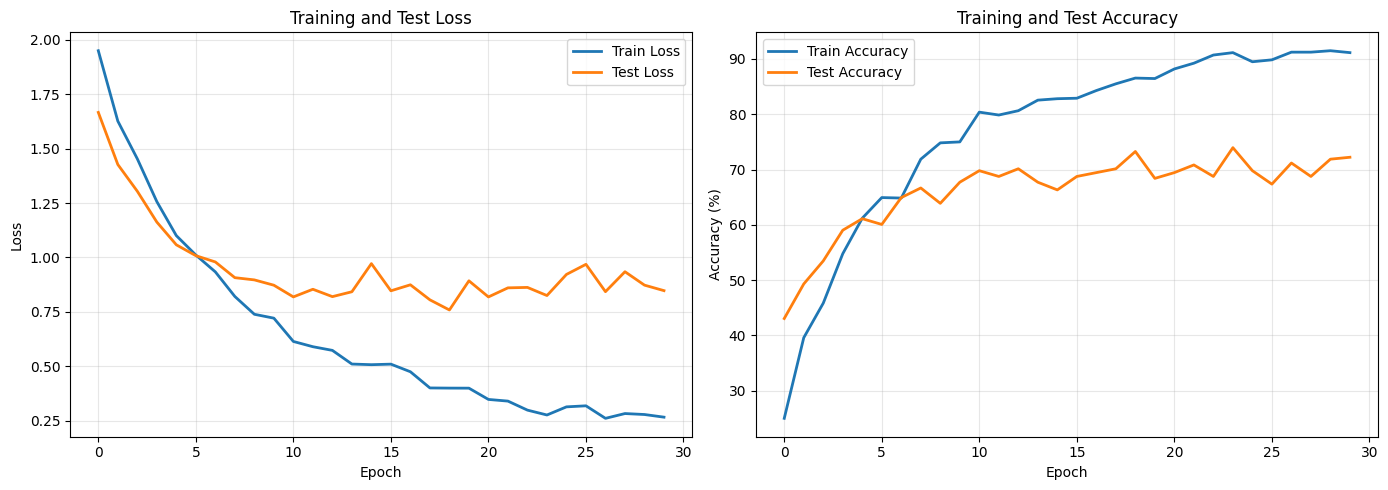


✓ Final Test Accuracy: 72.22%


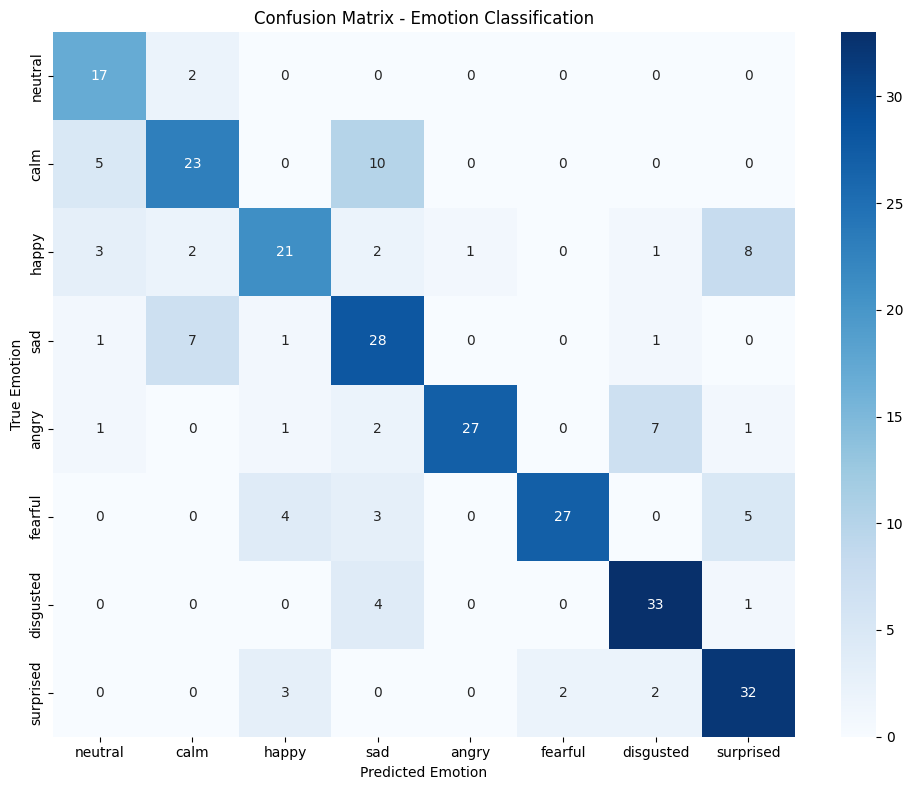


Classification Report:
              precision    recall  f1-score   support

     neutral       0.96      0.69      0.81        39
        calm       0.68      0.61      0.64        38
       happy       0.75      0.87      0.80        38
         sad       0.93      0.69      0.79        39
       angry       0.70      0.55      0.62        38
     fearful       0.63      0.89      0.74        19
   disgusted       0.57      0.74      0.64        38
   surprised       0.68      0.82      0.74        39

    accuracy                           0.72       288
   macro avg       0.74      0.73      0.72       288
weighted avg       0.75      0.72      0.72       288



In [ ]:
# Visualize training results
print("="*60)
print("STEP 4: Results and Visualization")
print("="*60)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(test_losses, label='Test Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Test Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(train_accs, label='Train Accuracy', linewidth=2)
axes[1].plot(test_accs, label='Test Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Test Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final evaluation
_, final_acc, all_preds, all_labels = evaluate(model, test_loader, nn.CrossEntropyLoss(), device)
print(f"\nFinal Test Accuracy: {final_acc:.2f}%")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS)
plt.title('Confusion Matrix - Emotion Classification')
plt.ylabel('True Emotion')
plt.xlabel('Predicted Emotion')
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:")
true_labels = [IDX_TO_EMOTION[idx] for idx in all_labels]
pred_labels = [IDX_TO_EMOTION[idx] for idx in all_preds]

unique_labels = sorted(set(true_labels + pred_labels))
if len(unique_labels) == len(EMOTION_LABELS):
    print(classification_report(true_labels, pred_labels, target_names=EMOTION_LABELS))
else:
    print(f"Note: Only {len(unique_labels)} emotion(s) present in test data: {unique_labels}")
    print(classification_report(true_labels, pred_labels, labels=unique_labels))